# 0 Imports

In [1]:
import sys
import os
sys.path.insert(0, os.path.abspath('..'))

import re

import pandas as pd

from src.suporte import funcoes_suporte as fs

## 0.1 Funções Suporte

In [2]:
fs.jupyter_settings(altura = 10, largura = 12, fonte = 8)
fs.supressao_notacao(casa_decimal = 2)

# 0.2 Load Data

In [3]:
df_raw = pd.read_csv('../data/raw/data.csv', encoding_errors="replace")
df_raw.sample(5)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
13035,537409,21259,VICTORIAN SEWING BOX SMALL,2,12/6/2010 15:00,5.95,15194.00,United Kingdom
36707,539451,22605,WOODEN CROQUET GARDEN SET,1,12/17/2010 16:59,25.49,NaN,United Kingdom
424213,573245,23266,SET OF 3 WOODEN STOCKING DECORATION,10,10/28/2011 12:08,1.25,17841.00,United Kingdom
540005,581454,22446,PIN CUSHION BABUSHKA PINK,12,12/8/2011 18:22,1.25,15156.00,United Kingdom
287325,562101,23209,LUNCH BAG DOILEY PATTERN,10,8/2/2011 14:04,1.65,13850.00,United Kingdom


# 1.0 Descrição dos Dados

## 1.1 Rename Columns

In [4]:
df_raw.columns = [fs.to_snake_case(col) for col in df_raw.columns]
df_raw.head()

,invoice_no,stock_code,description,quantity,invoice_date,unit_price,customer_id,country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.00,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.00,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.00,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.00,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.00,United Kingdom


## 1.2 Data Info

In [5]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   invoice_no    541909 non-null  object 
 1   stock_code    541909 non-null  object 
 2   description   540455 non-null  object 
 3   quantity      541909 non-null  int64  
 4   invoice_date  541909 non-null  object 
 5   unit_price    541909 non-null  float64
 6   customer_id   406829 non-null  float64
 7   country       541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


### 1.2.1 NA

In [6]:
df_raw.isna().sum()

invoice_no           0
stock_code           0
description       1454
quantity             0
invoice_date         0
unit_price           0
customer_id     135080
country              0
dtype: int64

In [7]:
df_raw = df_raw.dropna(subset=["description", "customer_id"])

## 1.3 Change Dtypes

In [8]:
df_raw["invoice_date"] = pd.to_datetime(df_raw["invoice_date"], format="%m/%d/%Y %H:%M").dt.normalize()

df_raw['customer_id'] = df_raw['customer_id'].astype(int)
df_raw.sample()

,invoice_no,stock_code,description,quantity,invoice_date,unit_price,customer_id,country
315524,564729,85204,HANGING WOOD AND FELT FLOWER,4,2011-08-28,0.12,13137,United Kingdom


In [9]:
df_raw.dtypes

invoice_no              object
stock_code              object
description             object
quantity                 int64
invoice_date    datetime64[ns]
unit_price             float64
customer_id              int64
country                 object
dtype: object

## 1.4 Estatística Descritiva Simples

In [10]:
var_num = df_raw.select_dtypes(include = ['int64','float64'])
var_cat = df_raw.select_dtypes(exclude = ['int64','float64'])

In [11]:
fs.estatistica_descritiva(var_num)

,variaveis,minimo,maximo,range,media,mediana,desvio_padrao,iqr,assimetria,curtosis,cv
0,quantity,-80995.00,80995.00,161990.00,12.06,5.00,248.69,10.00,0.18,94317.56,20.62
1,unit_price,0.00,38970.00,38970.00,3.46,1.95,69.32,2.50,452.22,246924.54,20.03
2,customer_id,12346.00,18287.00,5941.00,15287.69,15152.00,1713.60,2838.00,0.03,-1.18,0.11


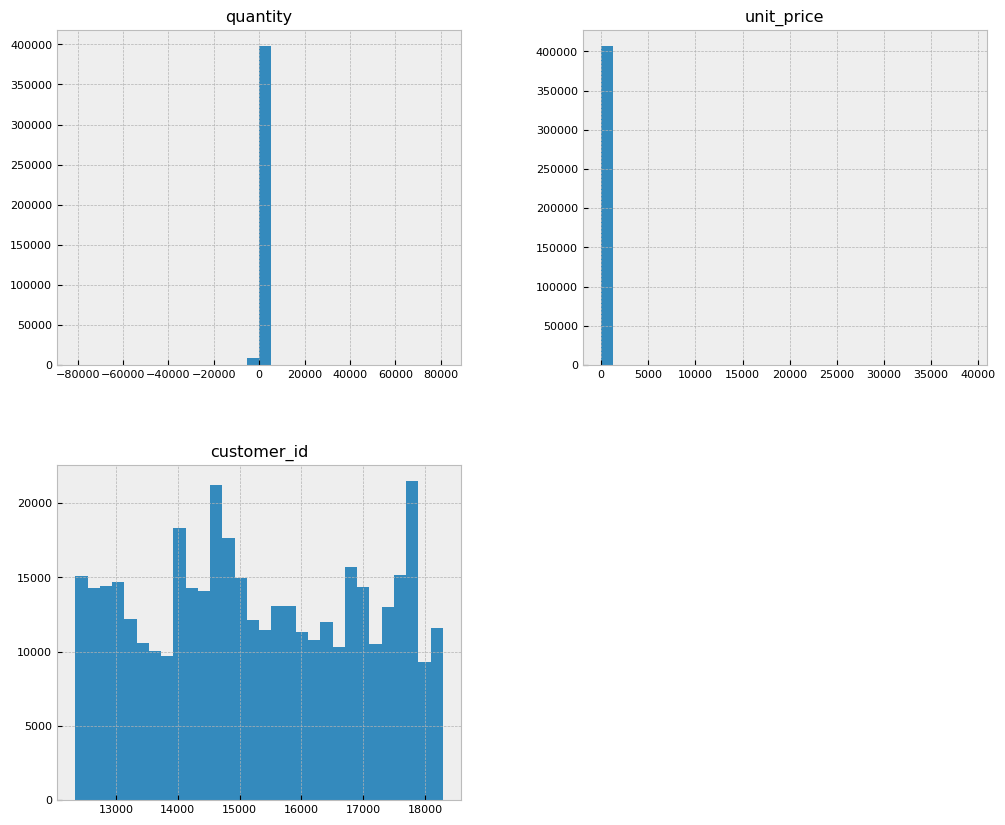

In [12]:
var_num.hist(bins=30);

### Análise Numérico

- quantity negativa, seriam devoluções?
- unit_price, tem produtos Zerados. Que tipo de produto é esse que está zerado? Veio de uma promoção?

In [13]:
# Domora muito devido a alta volumetria de dados categóricos. Comentei pra não ter que ficar rodando sempre
#fs.visualizacao_dados_categoricos(var_cat)

In [14]:
invoice_total_cat = len(df_raw.loc[df_raw['invoice_no'].apply( lambda x: bool(re.search('[^0-9]+', x) ) ), 'invoice_no'])
txt_itc = f"Total de valores com caracteres {invoice_total_cat}\n"

invoice_nduplicate_cat = len(df_raw.loc[df_raw['invoice_no'].apply( lambda x: bool(re.search('[^0-9]+', x) ) ), 'invoice_no'].drop_duplicates())
txt_indc = f"Valores com carateres sem duplicados {invoice_nduplicate_cat}\n"

invoice_onlytxt_cat = len(df_raw.loc[df_raw['invoice_no'].apply( lambda x: bool(re.search('^[a-zA-Z]+$', x) ) ), 'invoice_no'].unique())
txt_iotc = f"Valores de carateres só texto {invoice_onlytxt_cat}\n"

print(txt_itc,txt_indc,txt_iotc)

Total de valores com caracteres 8905
 Valores com carateres sem duplicados 3654
 Valores de carateres só texto 0



In [15]:
df_raw.loc[(df_raw['invoice_no'].apply( lambda x: bool(re.search('[^0-9]+', x) ) ) ) & (df_raw['quantity'] >= 0)].head()

,invoice_no,stock_code,description,quantity,invoice_date,unit_price,customer_id,country


1. invoice_co:
   1. Possui valores categóricos e numéricos.
   2. Os valores categóricos aparentemente referem-se a pedidos sem sucesso:
      1. Cancelados, Devolvidos, Modificados?
      2. Possivelmente o valor C antes dos números signifiquem cancelado.
   3. Os valores categóricos não possuem similar numérico. Ex.: C521540 ~= 521540. Se existisse similar, poderiamos checar os possíveis insucessos.
      1. Mesmo correlacionando com stock_code, não há um padrão determinado.
   4. Foi testado as seguintes combinações invoice_no & quantity para verificar a relação dos sucessos ou insucessos na compra, os resultados foram:
      1. invoice(txt) & quantity >=0 = SEM resultado. Compras com texto não possuem quantidades positivas. Verificar se o texto influencia no sucesso da compra. 
      2. ~invoice(txt) & quantity >=0 = COM resultado. Compras sem texto possuem quantidades positivas. Possivelmente são as compras comums. Possuem 397.924 linhas = 97,81% do df_raw.
      3. invoice(txt) & quantity <=0 = COM resultado. Compras com texto não possuem quantidades positivas. Talvez seja algum tipo de insucesso na compra. Possuem 8.905 linhas = 2,91% do df_raw. 
      4. ~invoice(txt) & quantity <=0 = SEM resultado. Compras sem texto não possuem quantidades positivas. Verificar se o texto influencia no sucesso da compra. 
      5. Conclusão: Aparentemente somente compras de insucesso possuem texto e com quantidades negativas. - `Tratrar, esta bagunçando o cluster`

In [16]:
stock_code_total_cat = len(df_raw.loc[df_raw['stock_code'].apply( lambda x: bool(re.search('[^0-9]+', x) ) ), 'stock_code'])
print(f"Total de valores com caracteres {stock_code_total_cat}")

stock_code_nduplicate_cat = len(df_raw.loc[df_raw['stock_code'].apply(lambda x: bool( re.search('[^0-9]+', x) ) ), 'stock_code'].drop_duplicates() )
print(f"Valores com carateres sem duplicados {stock_code_nduplicate_cat}")

stock_code_onlytxt_cat = len(df_raw.loc[df_raw['stock_code'].apply(lambda x: bool( re.search('^[a-zA-Z]+', x) ) ), 'stock_code'].unique() )
print(f"Valores de carateres só texto {stock_code_onlytxt_cat}")

stock_code_typetxt_cat = list(df_raw.loc[df_raw['stock_code'].apply(lambda x: bool( re.search('^[a-zA-Z]+', x) ) ), 'stock_code'].unique())
print(f"Lista de valores só caracteres {list(stock_code_typetxt_cat)}")

Total de valores com caracteres 35809


Valores com carateres sem duplicados 886
Valores de carateres só texto 8
Lista de valores só caracteres ['POST', 'D', 'C2', 'M', 'BANK CHARGES', 'PADS', 'DOT', 'CRUK']


In [ ]:
df_raw.loc[~(df_raw['stock_code'].isin(stock_code_typetxt_cat) ) & (df_raw['quantity'] >= 0) ]

2. stock_code:
   1. O stock code também está com valores categóricos.
   2. Esse valores pertencem a esta lista ['POST', 'D', 'C2', 'M', 'BANK CHARGES', 'PADS', 'DOT', 'CRUK']
   3. Todas as combinações de stock_code (com e sem texto) & (quantity >= ou <= 0) retornaram valores válidos.
      1. Destaco a combinação ~stock_code(in_lista) & quantity >=0. Retorna 396515 valores. Mas o stock_code ainda continha valores numéricos com strings associadas.

### Análise categórico


Para construir a segmentação de cliente temos que pensar, também nas devoluções, pois isso afeta diretamente o resultado do RFM. A baixo tem uma tabela simplificada com possíveis casos:
| RFM | Devolução | Perfil |
| ----- | ----- | ----- |
| Alta | Alta | Baixa aderência |
| Alta | Baixa | Alta aderência |
| Baixa | Alta | Péssima aderência |
| Baixa | Baixa | Qualificar o cliente |

1. invoice_no:
   1. Considerar dado negativo. Possibilidades:
      1. Calcular quantas devoluções a pessoa teve.
      2. Reorganizar os dados negativos, para demonstrar como devoluções.
      3. 

# 2.0 Exportar DF

In [18]:
path = "../data/interim/1.descricao.pkl"
fs.save_pickle(obj=df_raw, path=path)